<a href="https://colab.research.google.com/github/Pranoti15/My-DS-Projects/blob/my-branch/EDA_assignment4_concrete_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()  # Opens a file selection dialog

Saving concrete_data.csv to concrete_data.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

Mounted at /content/drive


In [4]:
# Move uploaded file to Google Drive
!mv concrete_data.csv "/content/drive/My Drive/Data Science/Kaggle Datasets"

In [5]:
import pandas as pd

file_path = "/content/drive/My Drive/Data Science/Kaggle Datasets/concrete_data.csv"  # Change to your folder path
df = pd.read_csv(file_path)
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [8]:
#Let's start with inspecting the summary statistics and checking for missing values.
# Display summary statistics of the dataset
summary_stats = df.describe()

# Check for missing values
missing_values = df.isnull().sum()

summary_stats, missing_values

(            cement  blast_furnace_slag      fly_ash        water  \
 count  1030.000000         1030.000000  1030.000000  1030.000000   
 mean    281.167864           73.895825    54.188350   181.567282   
 std     104.506364           86.279342    63.997004    21.354219   
 min     102.000000            0.000000     0.000000   121.800000   
 25%     192.375000            0.000000     0.000000   164.900000   
 50%     272.900000           22.000000     0.000000   185.000000   
 75%     350.000000          142.950000   118.300000   192.000000   
 max     540.000000          359.400000   200.100000   247.000000   
 
        superplasticizer  coarse_aggregate  fine_aggregate           age  \
 count       1030.000000       1030.000000      1030.000000  1030.000000   
 mean           6.204660        972.918932       773.580485    45.662136   
 std            5.973841         77.753954        80.175980    63.169912   
 min            0.000000        801.000000       594.000000     1.000000 

- **Summary Statistics**: The dataset contains various features with different ranges of values. The summary statistics show the distribution of the numerical variables:

For instance, cement ranges from 102 to 540, and age ranges from 1 to 365.

The concrete_compressive_strength has a wide range, from 2.33 to 82.6.

- **Missing Values**: There are no missing values in any of the columns in this dataset, which simplifies the data preparation process.

<Figure size 1200x1000 with 0 Axes>

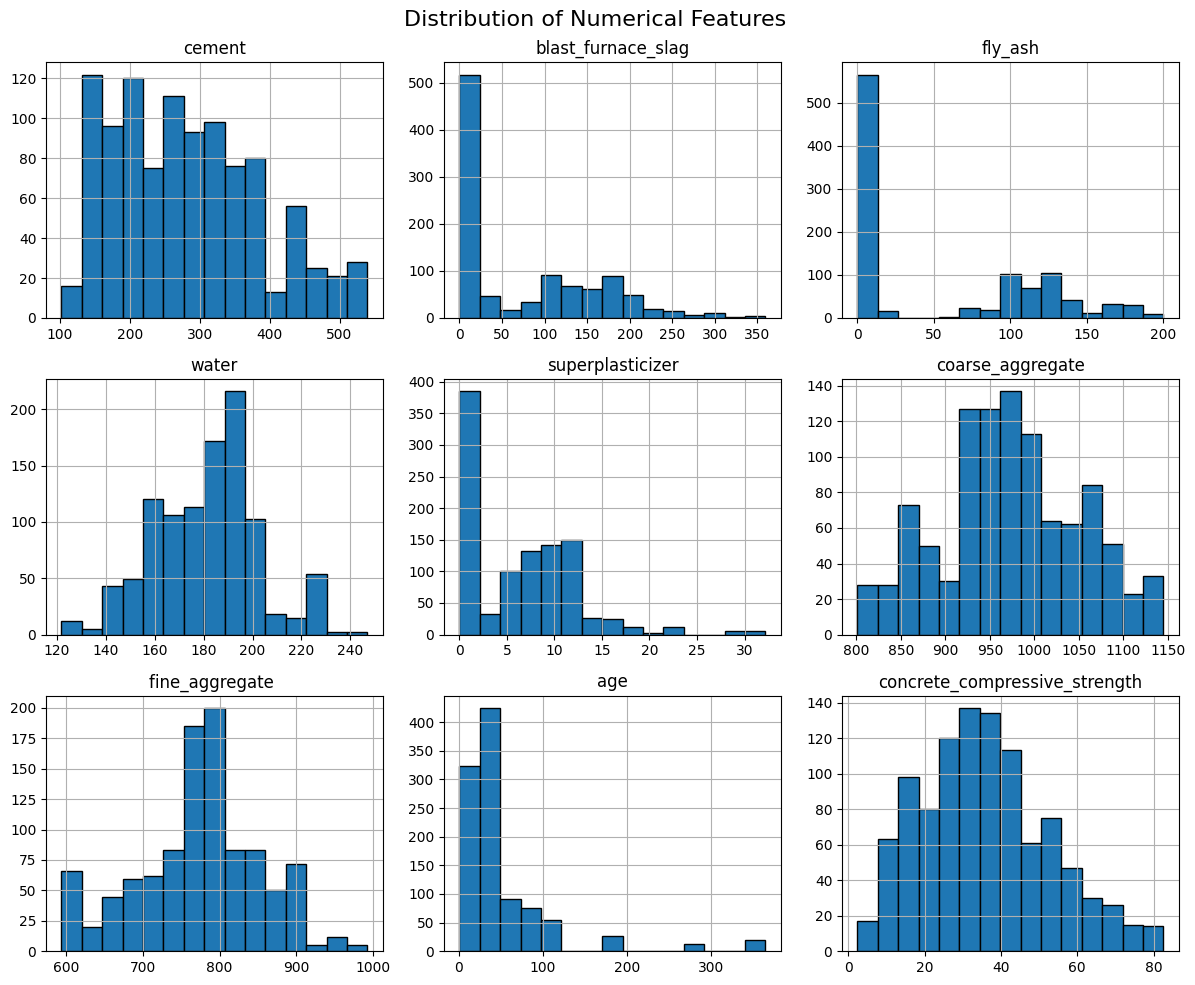

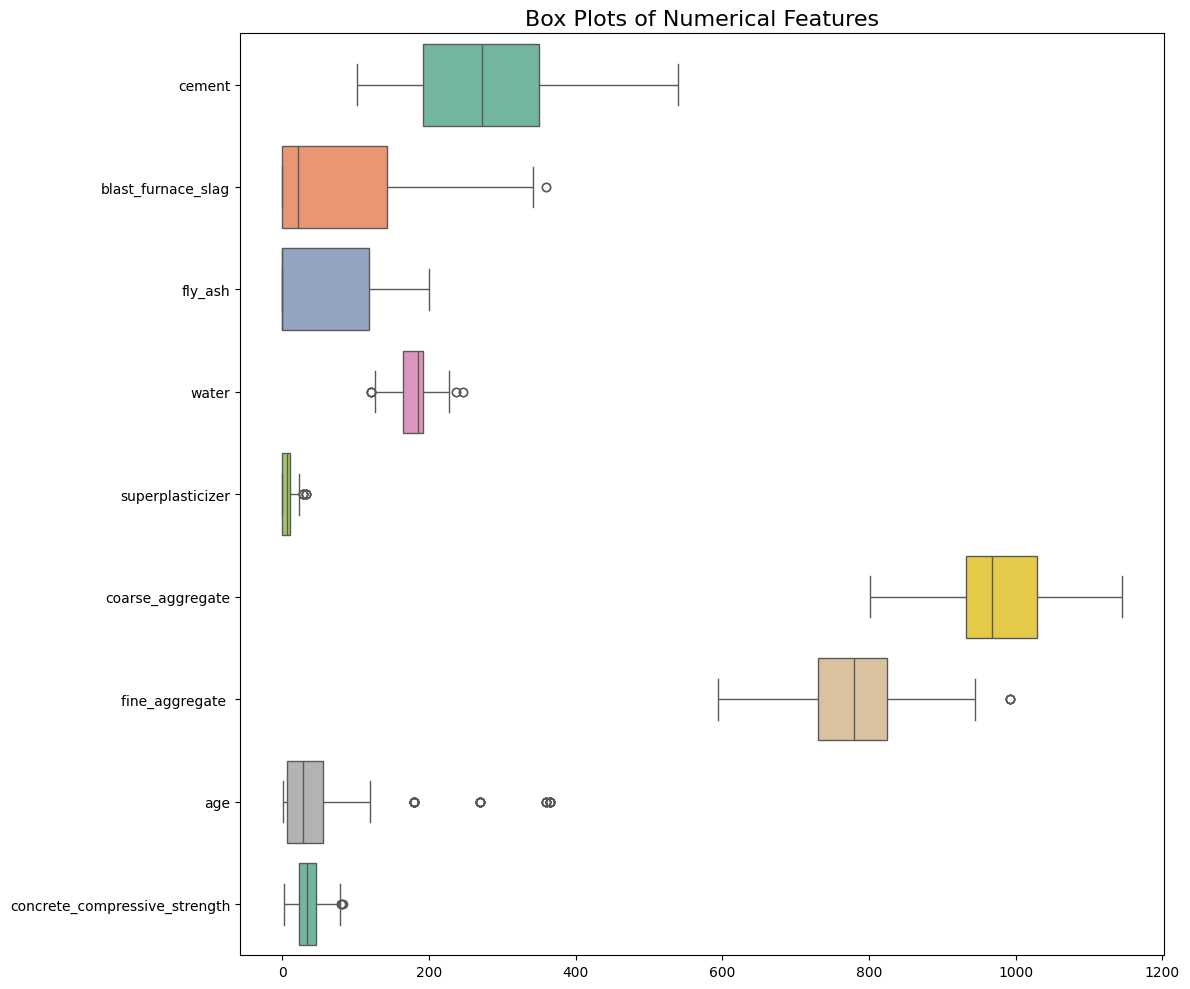

In [9]:
#Let’s start with visualizing the distributions of the numerical features using histograms and box plots.
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for plots
plt.figure(figsize=(12, 10))

# Plot histograms for numerical features
df.hist(bins=15, figsize=(12, 10), edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# Plot box plots for numerical features
plt.figure(figsize=(12, 10))
sns.boxplot(data=df, orient="h", palette="Set2")
plt.title('Box Plots of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


**Step 2: Exploratory Data Analysis**

**Histograms**: The histograms show the distributions of the numerical features in the dataset. Features like cement, fly_ash, and water appear to have skewed distributions, while others like superplasticizer show a more uniform distribution.

**Box Plots**: The box plots highlight potential outliers in certain features, such as superplasticizer, cement, and fly_ash. These outliers could be worth investigating further, especially for model training.

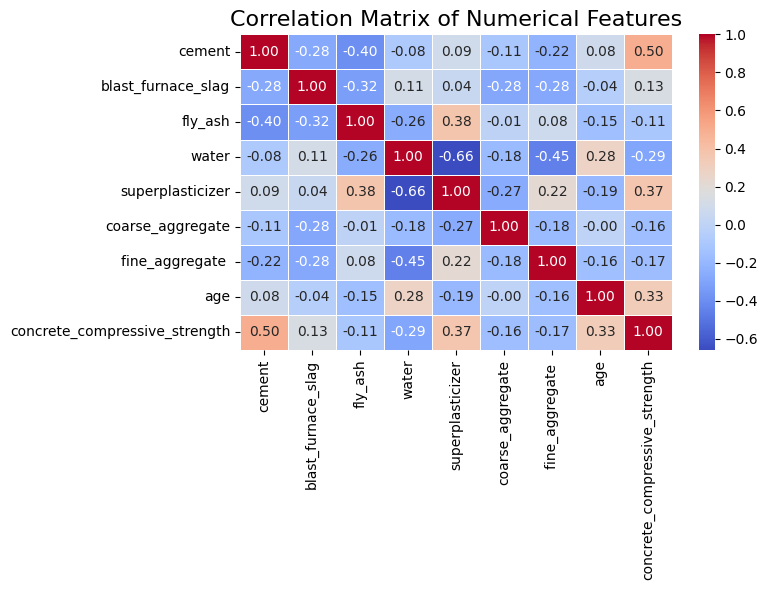

In [11]:
#We can proceed to check the correlation between numerical features using a correlation matrix and then normalize the features that require scaling.
# Correlation matrix
correlation_matrix = df.corr()

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


**Step 3: Preprocessing Steps**

**Correlation Matrix**: The correlation matrix reveals the relationships between different features. Some observations:

There is a strong positive correlation between cement and water, and between cement and superplasticizer.

The concrete_compressive_strength shows a moderate correlation with cement, age, and water.

**Step 4: Summary of Insights**

Based on the EDA so far, here are some insights:

**Key Observations:**

- cement appears to be a strong contributor to concrete_compressive_strength, which aligns with domain knowledge in concrete mix design.

- age seems to have a notable impact on the compressive strength of the concrete.

- The presence of outliers, especially in cement, superplasticizer, and fly_ash, should be considered for model robustness.

#The END